In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import os
import logging
import h5py
import matplotlib.pyplot as plt  # type: ignore
import numpy as np
import healpy as hp
from itertools import product

from mlpng.utils import (
    setup_logging,
    plot_cl_alm,
    plot_predictions,
    plot_histogram,
    plot_elsner_comp,
    save_data,
    remove_mono_dipole,
    # pol_str,
    make_alm_plots,
)
from mlpng.generator import Generator
from mlpng.utils.utils import print_errors

logger = setup_logging(__name__, level=logging.DEBUG)

mpi_comm = None

2025-06-03 08:42:10.053152: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-03 08:42:10.079565: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-03 08:42:10.079588: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-03 08:42:10.080458: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-03 08:42:10.084965: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-03 08:42:10.085370: I tensorflow/core/platform/cpu_feature_guard.cc:1

## Setup

In [3]:
generator = Generator(
    [
        "settings/n32.json",
        "--nsims",
        "300",
        "--narray",
        "1",
        "--fnl_range",
        "-1000",
        "1000",
        "--pols",
        "T",
        "--phi_scale",
        "10.0",
        # "--shape",
        # "local",
        # "--no-noise",
        # "--mc_steps",
        # "100",
        # "--nside",
        # "128",
        # "--lmax",
        # "383",
    ]
)

# check if we actually need to run / clean files
# generator.check_existing_data_file()

# generator.run()

03-Jun-25 08:42:12 - mlpng.core - DEBUG - Parsing CLI args: ['settings/n32.json', '--nsims', '300', '--narray', '1', '--fnl_range', '-1000', '1000', '--pols', 'T', '--phi_scale', '10.0']
03-Jun-25 08:42:12 - mlpng.core - INFO - Loading settings from file 'settings/n32.json'
03-Jun-25 08:42:12 - mlpng.core - DEBUG - Forcing setting 'nsims' to 300 due to CLI
03-Jun-25 08:42:12 - mlpng.core - DEBUG - Forcing setting 'narray' to 1 due to CLI
03-Jun-25 08:42:12 - mlpng.core - DEBUG - Forcing setting 'fnl_range' to [-1000, 1000] due to CLI
03-Jun-25 08:42:12 - mlpng.core - DEBUG - Forcing setting 'pols' to T due to CLI
03-Jun-25 08:42:12 - mlpng.core - DEBUG - Forcing setting 'phi_scale' to 10.0 due to CLI
03-Jun-25 08:42:12 - mlpng.core - DEBUG - Overriding cosmo param 'As' from 2.13e-09 to 2.457e-09
03-Jun-25 08:42:12 - mlpng.core - DEBUG - Overriding cosmo param 'ns' from 0.9624 to 0.9649
03-Jun-25 08:42:12 - mlpng.core - DEBUG - Running with settings: 
{
  "cosmo_params": {
    "As": 2.4

In [4]:
pol_idxs = generator.pol_idxs()

alm_l = generator.generate_alm()
alm_nl = generator.generate_alm_nl(alm_l)
# alm_nl = generator.generate_alm_nl_shape(alm_l, "local")
fnls = generator.rng.uniform(
    generator.fnl_min, generator.fnl_max, (generator.total_sims, 1, 1)
)

# Add the duplicate dimension to the alms
alm_l = alm_l[:, pol_idxs]

# finally combine into the full alms and remove the monopole and dipole terms
alms = alm_l + fnls * alm_nl

03-Jun-25 08:42:17 - mlpng.generator - DEBUG - Using temp folder for alm_nl generation: /lustre/scratch/client/users/stevensonb
03-Jun-25 08:42:17 - mlpng.generator - DEBUG - Starting...


alm_nl:   0%|          | 0/300 [00:00<?, ?it/s]

2025-06-03 08:42:20.861574: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-03 08:42:20.881111: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-03 08:42:20.885970: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-03 08:42:20.889128: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-03 08:42:20.889443: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-03 08:42:20.891652: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-03 08:42:20.891694: E external/local_xla/xla/stream_executor/

In [5]:
# logger.info("Starting lensing")
# alm_lensed = generator.lens_alms(alms)

# maps_lensed = np.zeros(generator.map_shape, dtype=generator.r_dtype)
# for sim, dup in product(range(generator.nsims), range(generator.ndups)):
#     rmap = hp.alm2map(alm_lensed[sim], nside=generator.nside, pol=generator.use_pols)
#     maps_lensed[sim, dup] = hp.reorder(rmap, r2n=True)

## Alm

(300, 1, 4656) (300, 1, 4656) (300, 1, 4656)


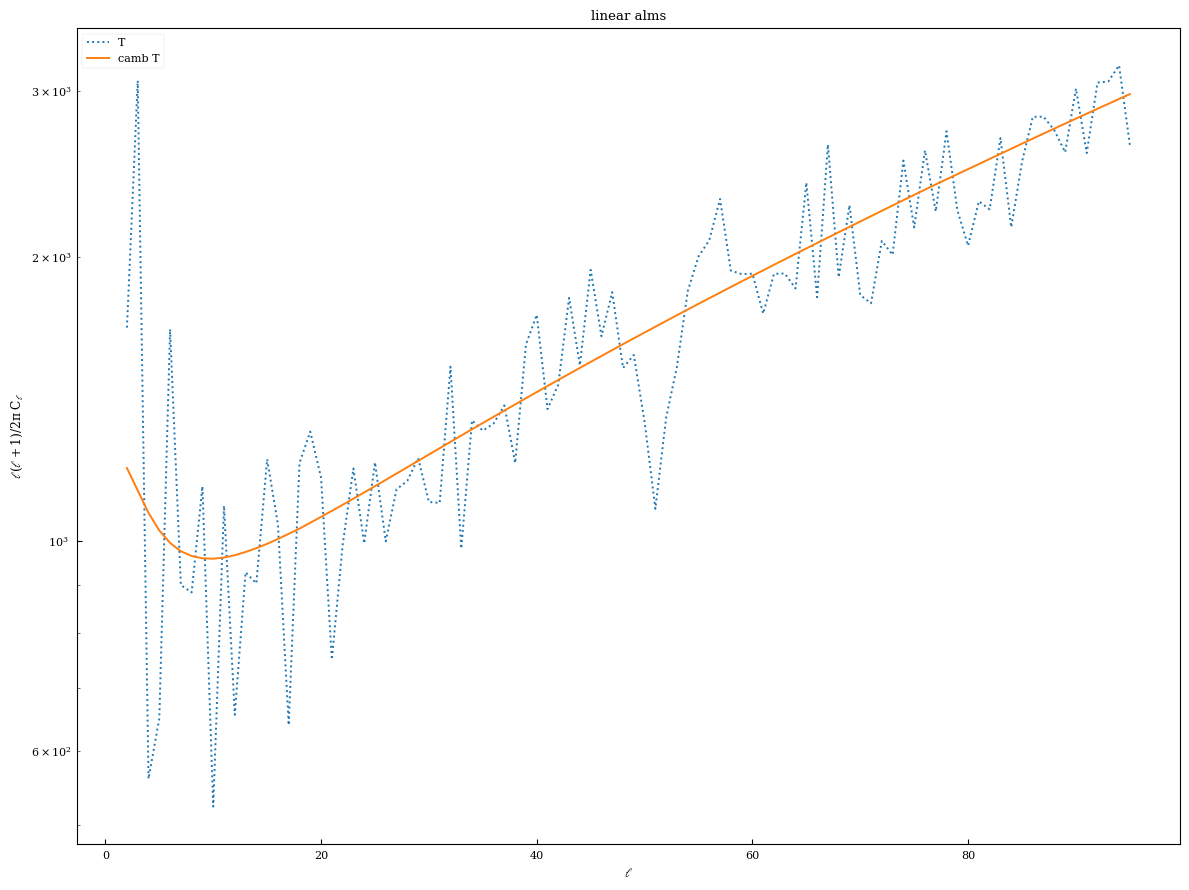

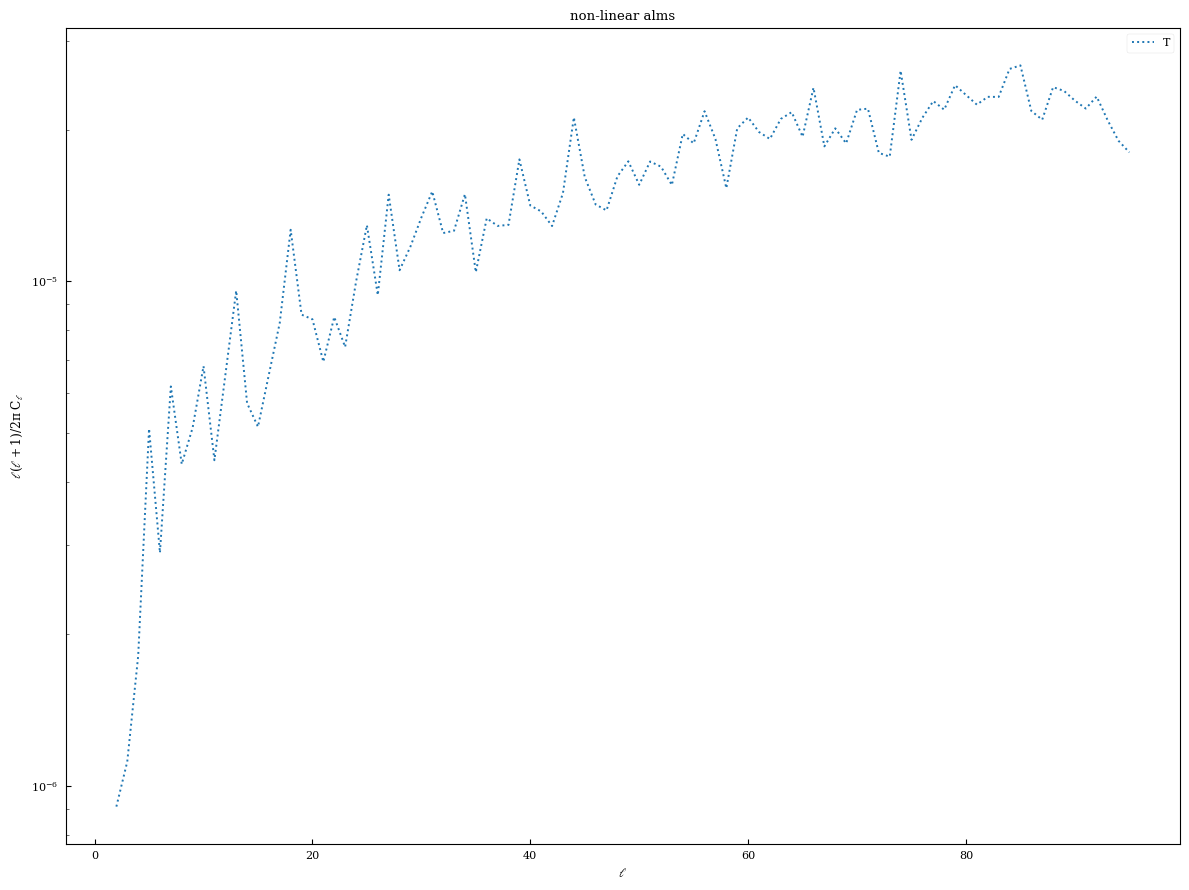

In [6]:
print(alm_l.shape, alm_nl.shape, alms.shape)
plot_cl_alm(
    generator,
    alm_l[0],
    title="linear alms",
    # labels=plt_labels,
    plot_camb=True,
    plot_noise=False,
    plot_full_camb=False,
    show=True,
)

ells = np.arange(generator.nell)
scale = (ells * (ells + 1)) / (2 * np.pi)

plot_cl_alm(
    generator,
    alm_nl[0],
    title="non-linear alms",
    plot_camb=False,
    plot_noise=False,
    plot_full_camb=False,
    show=True,
    scale=True,
)

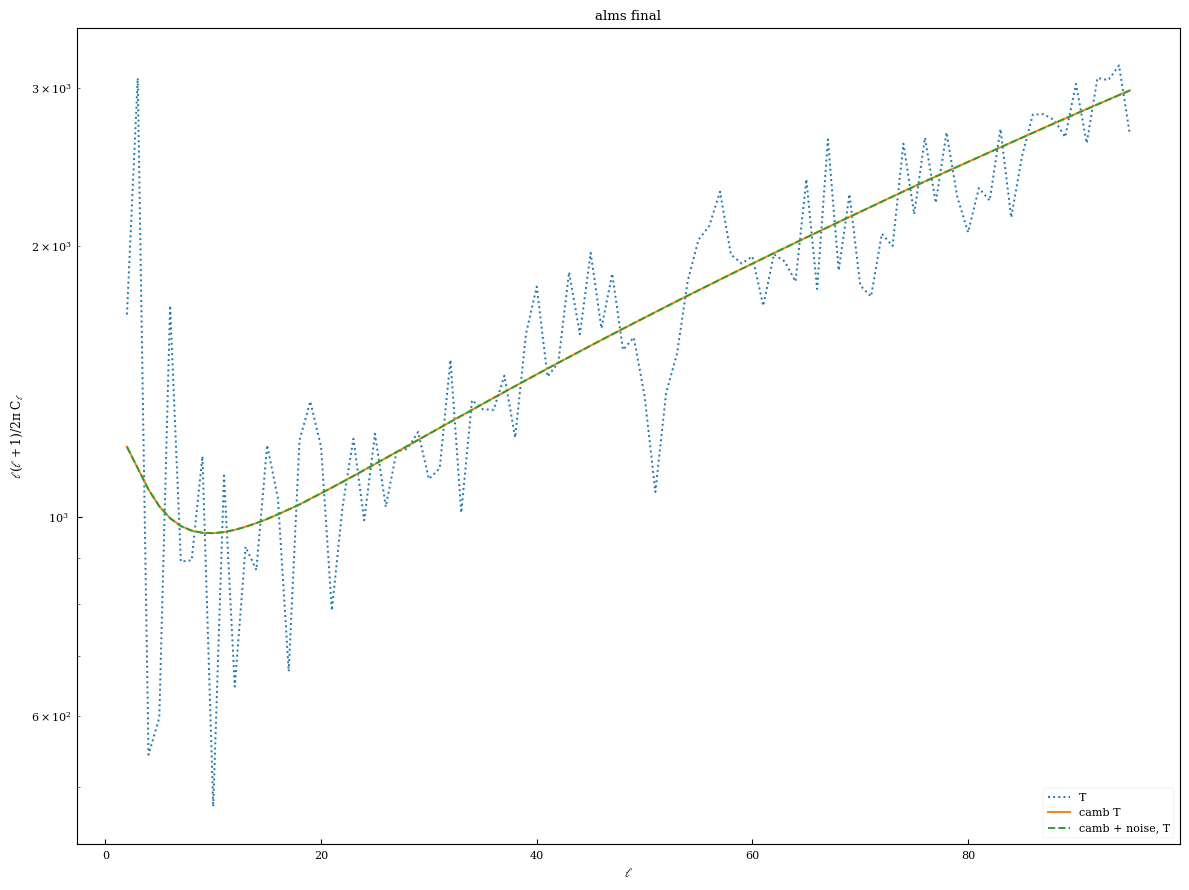

In [7]:
plot_cl_alm(
    generator,
    alms[0],
    title="alms final",
    plot_camb=True,
    plot_noise=False,
    plot_full_camb=True,
    show=True,
)

03-Jun-25 08:43:58 - mlpng.utils.plots - DEBUG - Mean ratio of alm T: 18832.600190822934
03-Jun-25 08:43:58 - mlpng.utils.plots - DEBUG - Mean ratio of elsner T: 13292.09884690435


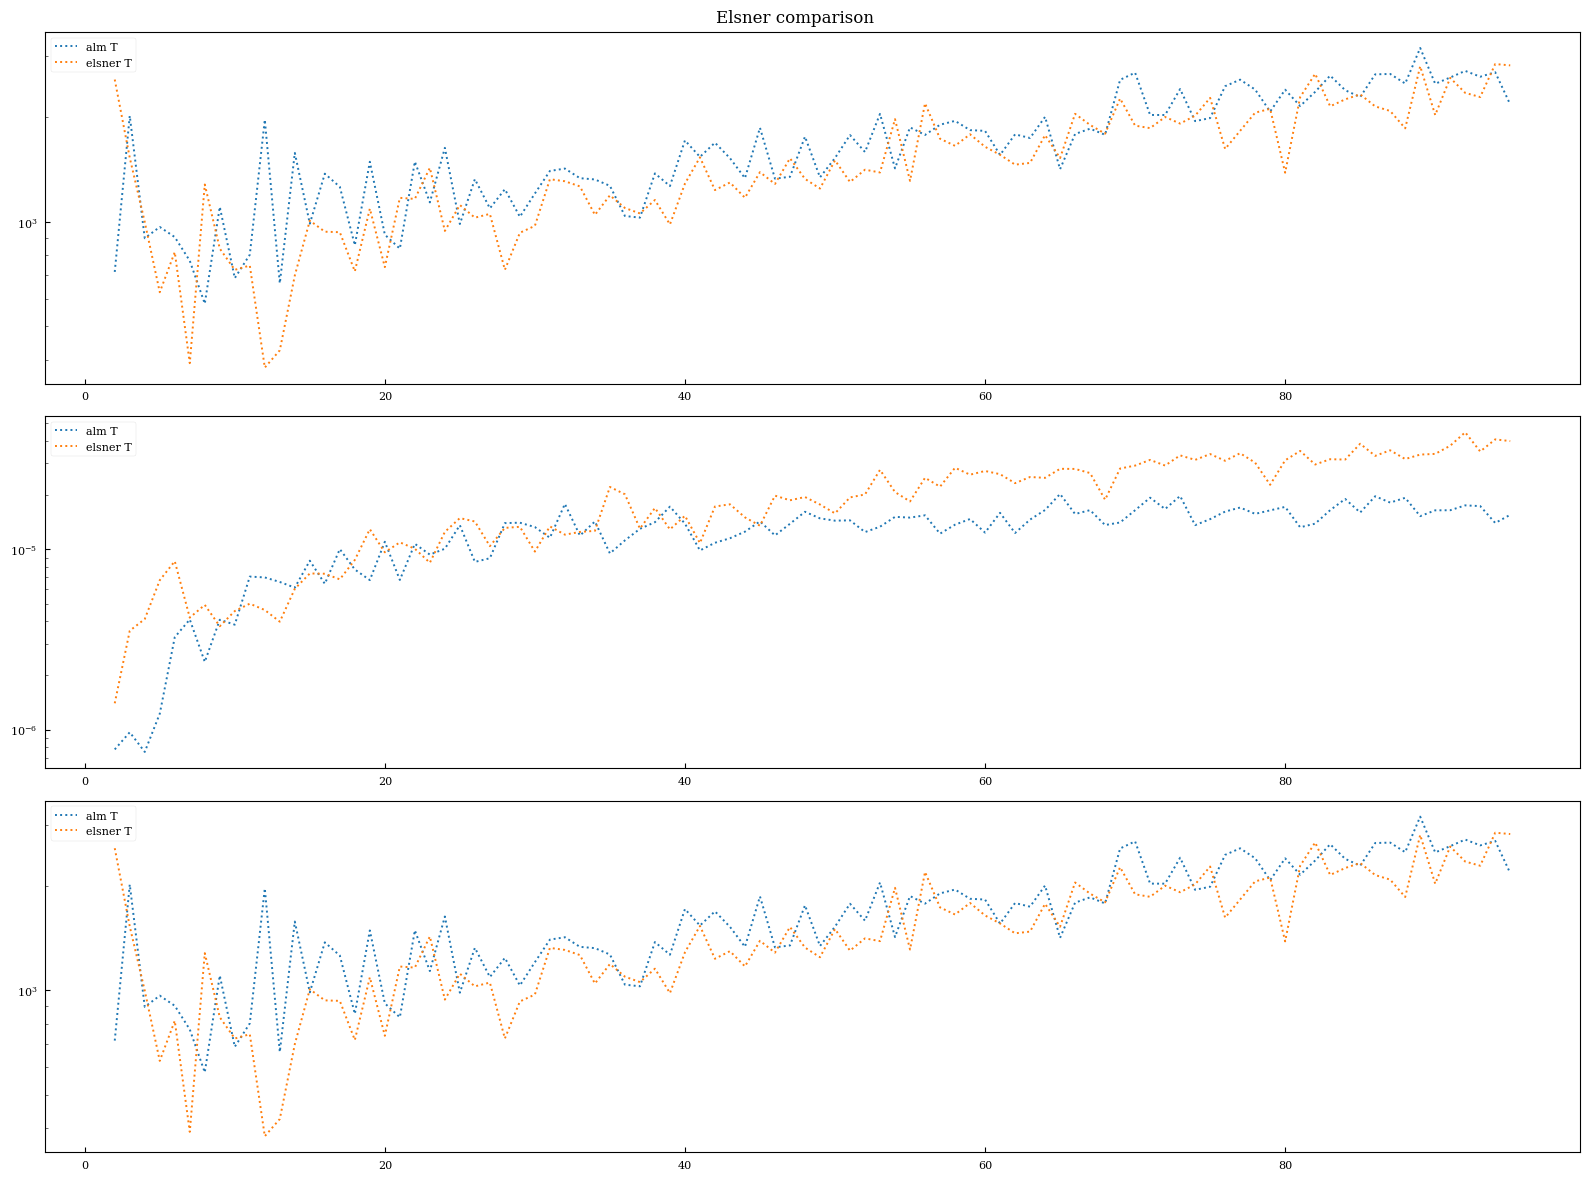

03-Jun-25 08:43:59 - mlpng.utils.plots - DEBUG - Mean ratio of alm T: 18832.600190822934
03-Jun-25 08:43:59 - mlpng.utils.plots - DEBUG - Mean ratio of elsner T: 13292.09884690435


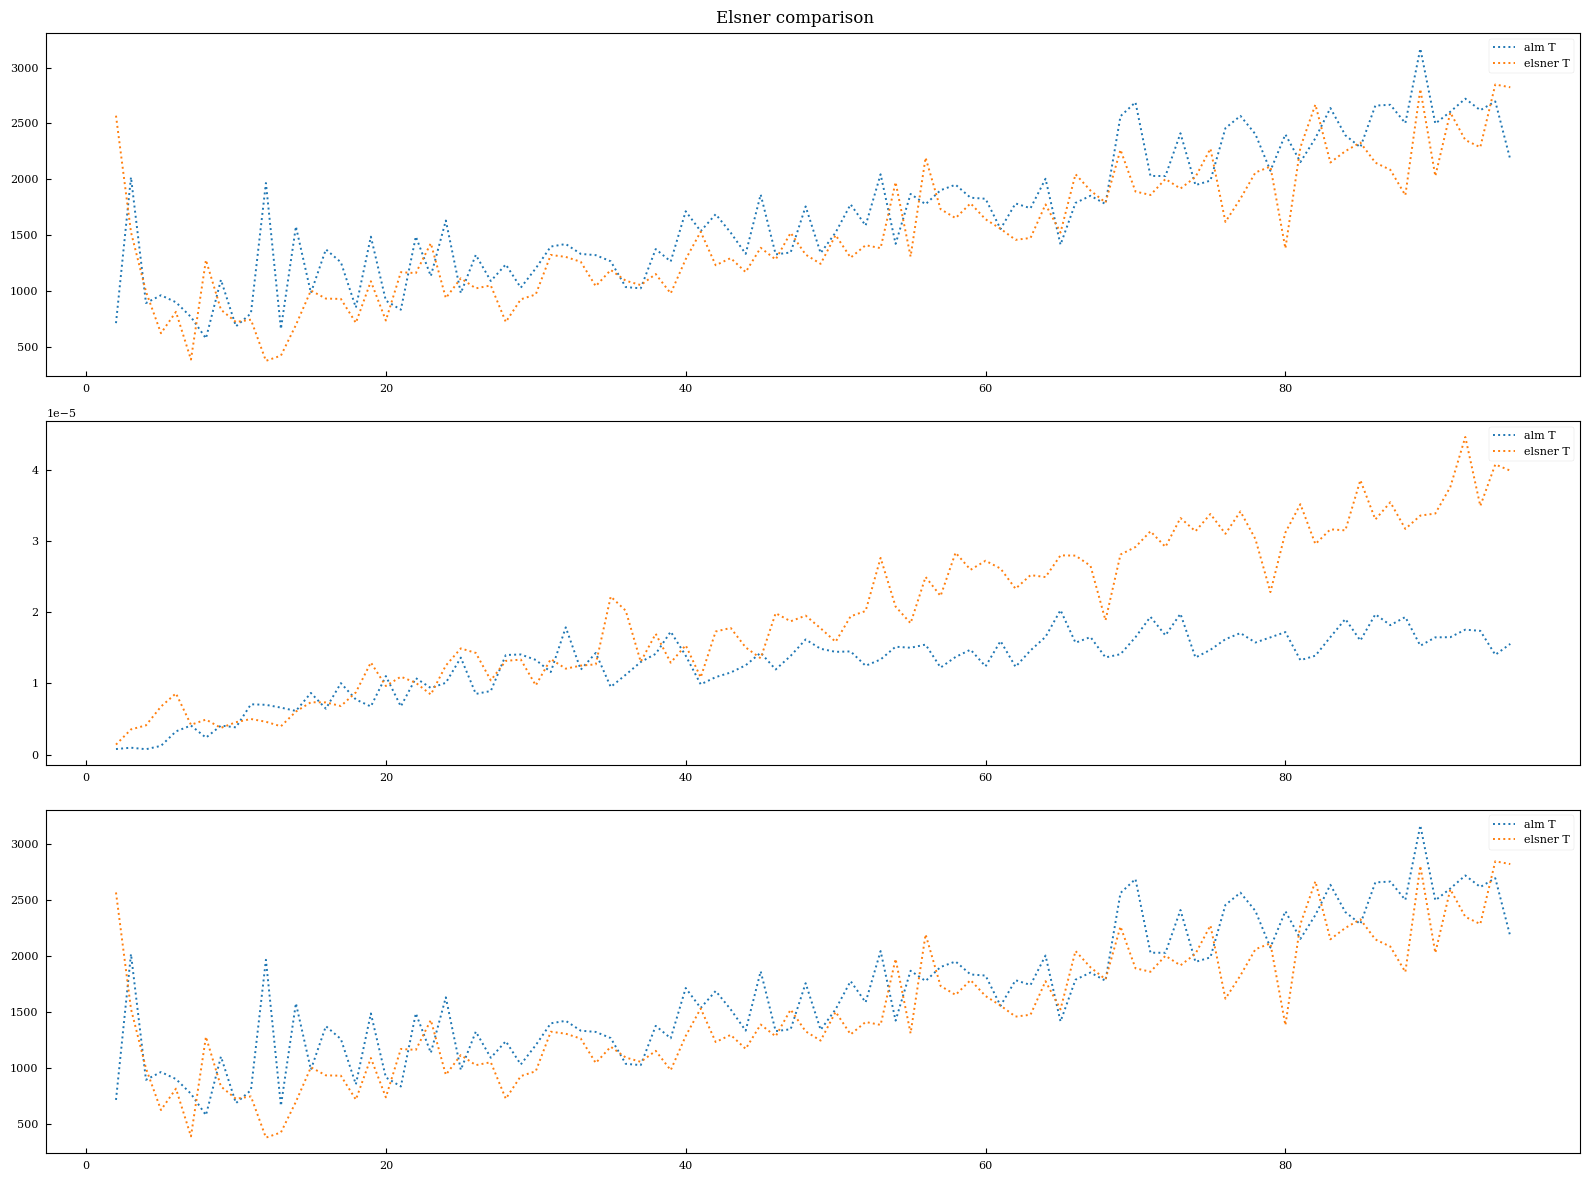

03-Jun-25 08:43:59 - mlpng.utils.plots - DEBUG - Mean ratio of alm T: 18832.600190822934
03-Jun-25 08:43:59 - mlpng.utils.plots - DEBUG - Mean ratio of elsner T: 13292.09884690435


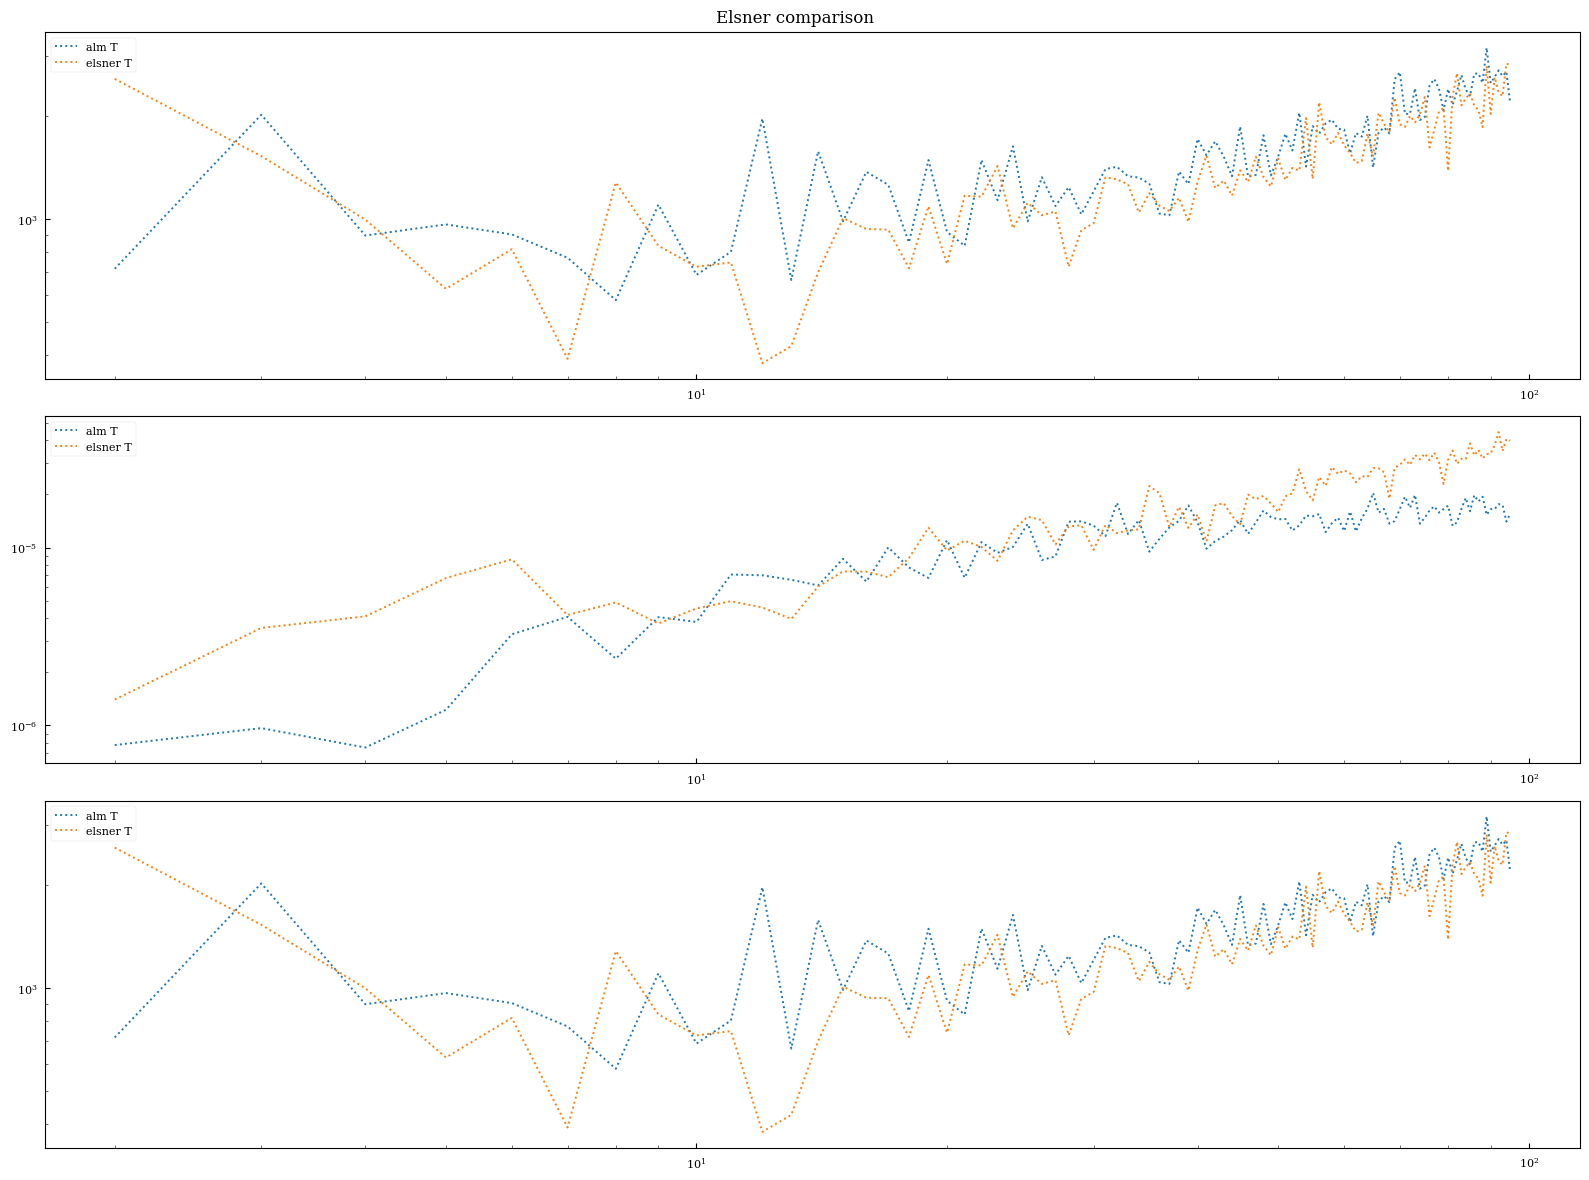

In [8]:
sim = generator.rng.integers(generator.nsims)
eidx = generator.rng.integers(1, 1001)
plot_elsner_comp(
    generator,
    alm_l[sim],
    alm_nl[sim],
    index=eidx,
    show=True,
    plot_func=plt.semilogy,
)
plot_elsner_comp(
    generator,
    alm_l[sim],
    alm_nl[sim],
    index=eidx,
    show=True,
    plot_func=plt.plot,
)
plot_elsner_comp(
    generator,
    alm_l[sim],
    alm_nl[sim],
    index=eidx,
    show=True,
    plot_func=plt.loglog,
)

03-Jun-25 08:44:01 - mlpng.utils.plots - DEBUG - Averaging 300 elsner sims, this will take a while


Averaging elsner sims:   0%|          | 0/300 [00:00<?, ?it/s]

03-Jun-25 08:48:50 - mlpng.utils.plots - DEBUG - Mean ratio of alm T: 18820.392337456975
03-Jun-25 08:48:50 - mlpng.utils.plots - DEBUG - Mean ratio of elsner T: 13823.015839443811


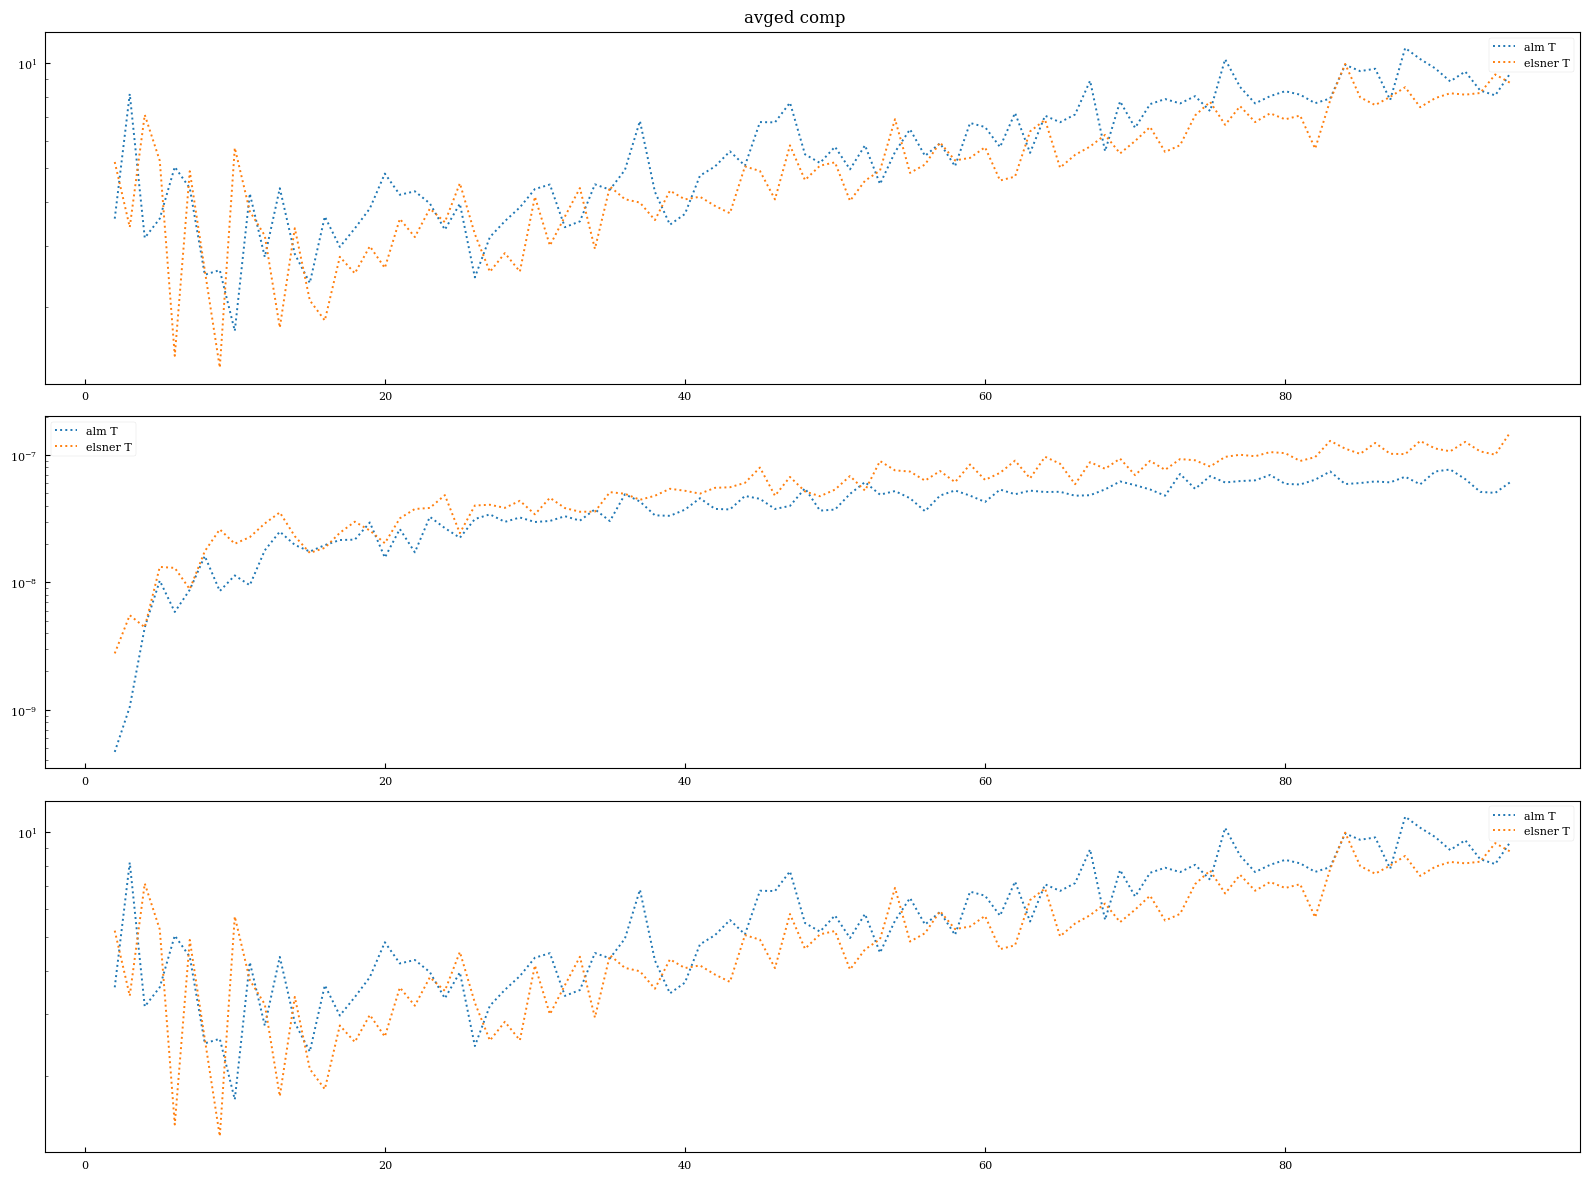

In [9]:
alm_l_avg = np.mean(alm_l, axis=0)
alm_ng_avg = np.mean(alm_nl, axis=0)

plot_elsner_comp(
    generator,
    alm_l_avg,
    alm_ng_avg,
    average=generator.nsims,
    title="avged comp",
    show=True,
    plot_func=plt.semilogy,
)

## Estimator

In [10]:
mpi_size = 1

# the KSW code requires the total_sims to be >= mpi_size
# best usage would have total_sims % mpi_size == 0, but not required
assert generator.num_estimates >= mpi_size, (
    "total_sims < mpi_size, lower ntasks or increase sims"
)

logger.info(
    "Computing %s estimates in %.2f batches",
    generator.num_estimates,
    generator.num_estimates / mpi_size,
)
if generator.num_estimates % mpi_size != 0:
    logger.warning(
        "num_estimates is not divisible by mpi_size, "
        "this will lead to uneven workloads."
    )

# The default theta_batch size is 25, which is really small, we want to increase it
theta_batch = int(np.floor(1.5 * generator.lmax + 1)) // mpi_size
logger.debug("Using theta_batch %s", theta_batch)


# alm_steps = generator.generate_alm(nsims=generator.mc_steps)

logger.info("Initializing KSW with %s steps", generator.mc_steps)
ksw = generator.get_ksw("local", step_alms=alm_l)
fisher = ksw.compute_fisher()
print(f"Fisher: {fisher}, standard deviation: {1 / np.sqrt(fisher)}")

03-Jun-25 08:48:52 - __main__ - INFO - Computing 300 estimates in 300.00 batches
03-Jun-25 08:48:52 - __main__ - DEBUG - Using theta_batch 143
03-Jun-25 08:48:52 - __main__ - INFO - Initializing KSW with 300 steps
03-Jun-25 08:48:56 - mlpng.generator - DEBUG - Initalizing KSW for shape local with 300 steps, lensing: False
Fisher: 0.0001372438664468076, standard deviation: 85.35982729548498


03-Jun-25 08:49:46 - mlpng.utils.utils - INFO - Standard deviation from fisher: 85.35982729548498, SEM: 4.9282519267028215
03-Jun-25 08:49:46 - mlpng.utils.utils - INFO - Mean error: 1.14699588037112, Median error: 5.497624603605516
03-Jun-25 08:49:46 - mlpng.utils.utils - INFO - 55.333333333333336% (52.0, 57.99999999999999) are within 1 standard deviations
03-Jun-25 08:49:46 - mlpng.utils.utils - INFO - 88.66666666666667% (85.33333333333334, 89.66666666666666) are within 2 standard deviations
03-Jun-25 08:49:46 - mlpng.utils.utils - INFO - 96.66666666666667% (95.33333333333334, 97.0) are within 3 standard deviations
03-Jun-25 08:49:46 - mlpng.utils.utils - INFO - 99.33333333333333% (99.0, 99.33333333333333) are within 4 standard deviations
03-Jun-25 08:49:46 - mlpng.utils.utils - INFO - 100.0% (99.66666666666667, 100.0) are within 5 standard deviations


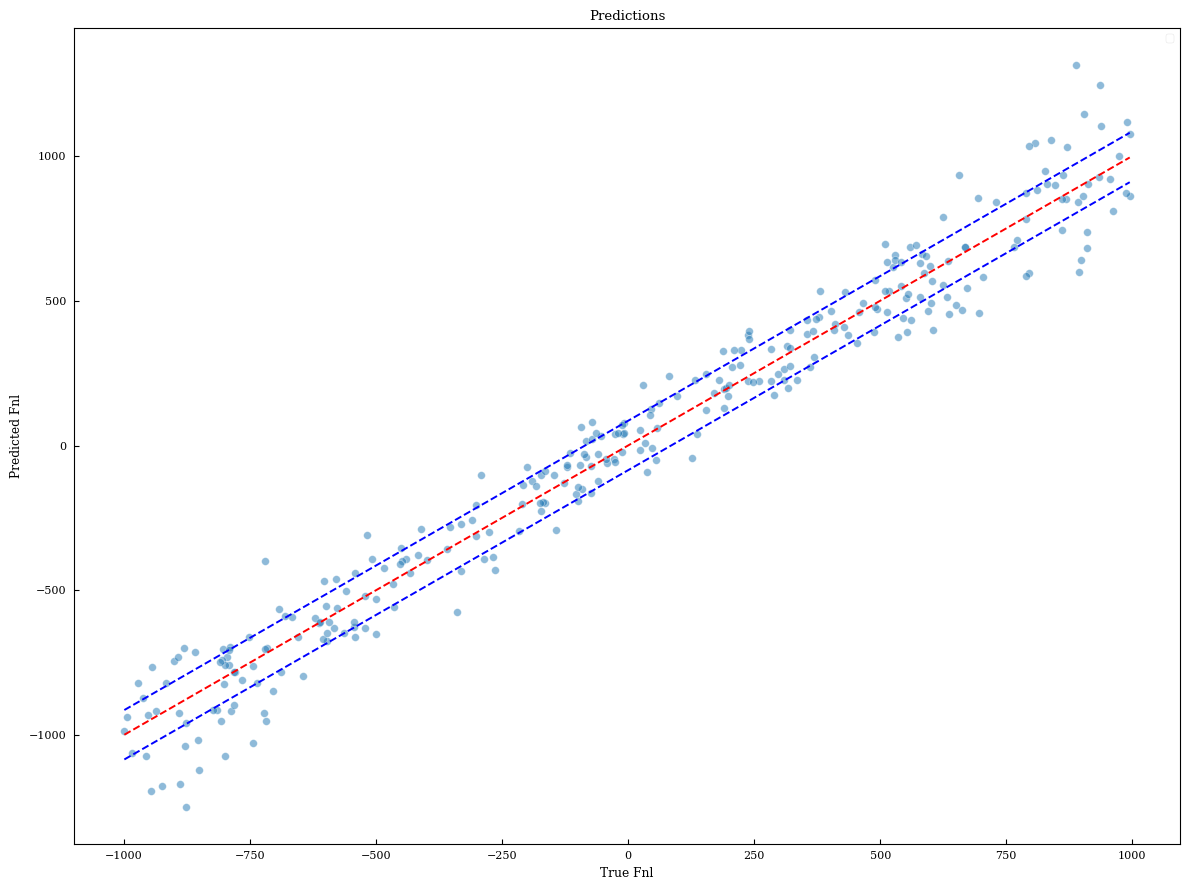

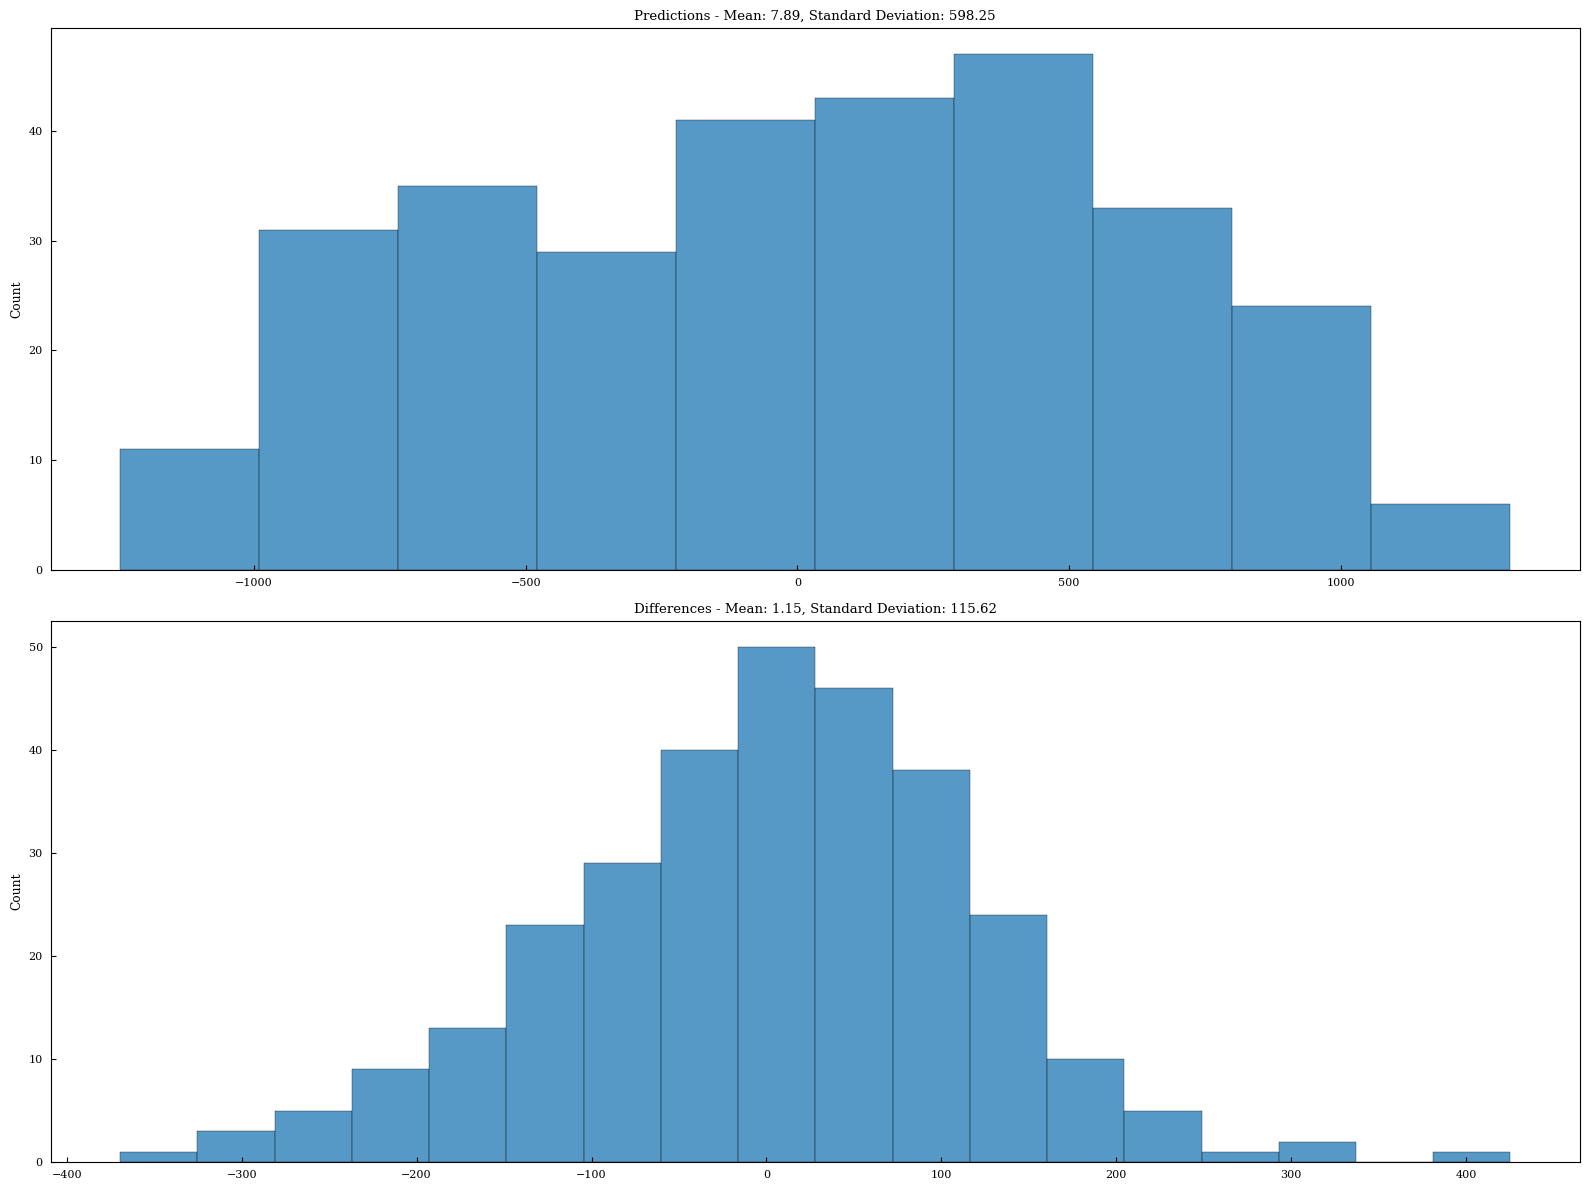

In [11]:
estimates, cubic, linear, fishers = ksw.compute_estimate_batch(
    lambda idx: generator.icov_func(alms[idx]),
    range(generator.nsims),
    # theta_batch=int(np.floor(1.5 * generator.lmax + 1)) // generator.slurm.n_cpus,
    fisher=fisher,
    # lin_term=0,
)

# print(cubic)
# print(linear)
# print(fishers)

fnls_flat = fnls.flatten()
print_errors(fnls_flat, estimates, fisher)
plot_predictions(fnls_flat, estimates, sigma=1 / np.sqrt(fisher), show=True)
plot_histogram(fnls_flat, estimates, show=True)

## Lensing

In [16]:
alm_lensed = generator.lens_alms(alms)

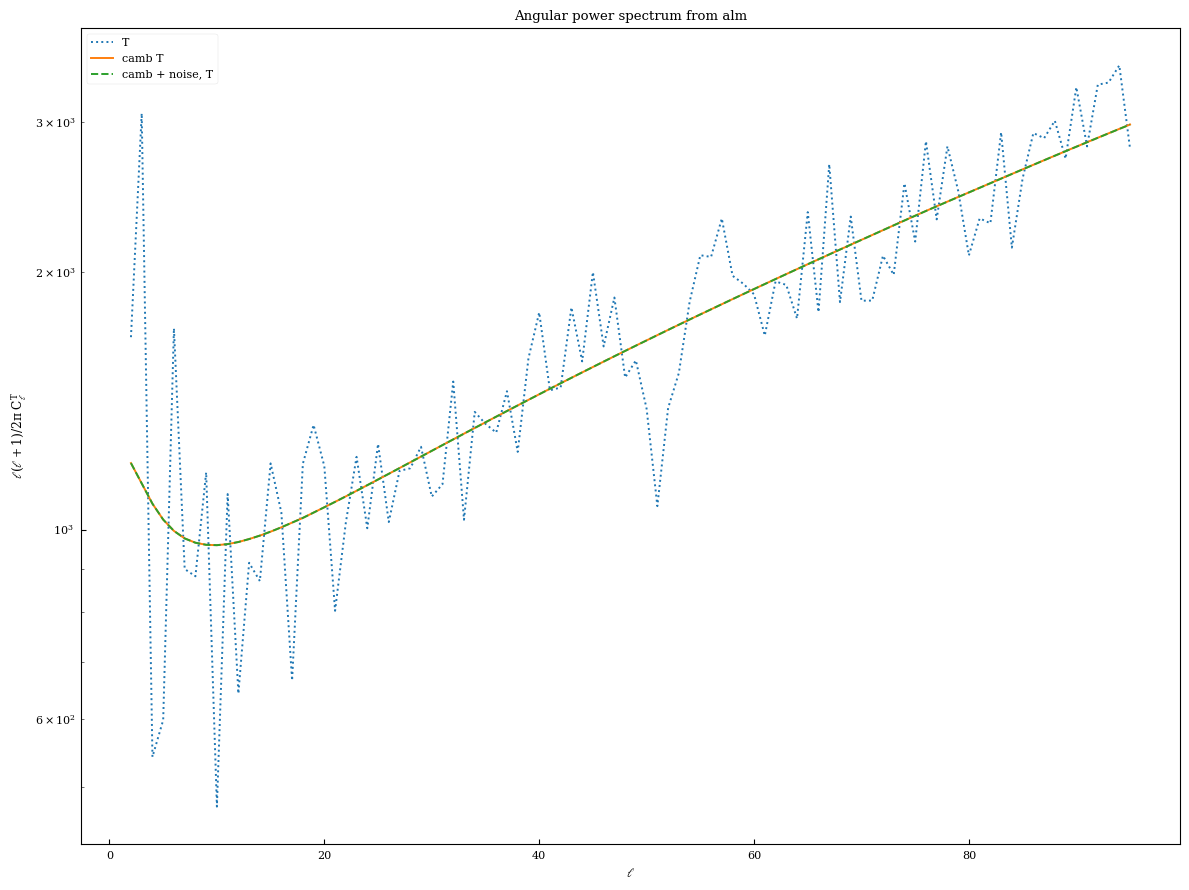

In [17]:
sim = 0
for i, pol in enumerate(generator.pol_idxs()):
    pstr = generator.pols[pol]

    ylabel = r"$\ell(\ell+1)/2\pi\;C_{\ell}" + f"^{pstr}$"
    plot_cl_alm(
        generator,
        alm_lensed[sim, i],
        # save_file=filebase,
        ylabel=ylabel,
        plot_camb=True,
        plot_noise=False,
        plot_full_camb=True,
        show=True,
        lmin=2,
    )

In [19]:
lens_estimates, _, _, _ = ksw.compute_estimate_batch(
    lambda a: generator.icov_func(
        alm_lensed[a, generator.pol_idxs(pretrimmed=True)]
    ),
    range(generator.nsims),
    theta_batch=int(np.floor(1.5 * generator.lmax + 1)) // generator.slurm.n_cpus,
    fisher=fisher,
    lin_term=0,
)

fnl shape (300, 1, 1) estimates shape (300,) fisher 0.0001372438664468076
03-Jun-25 10:18:52 - mlpng.utils.utils - INFO - Standard deviation from fisher: 85.35982729548498, SEM: 4.9282519267028215
03-Jun-25 10:18:52 - mlpng.utils.utils - INFO - Mean error: 0.1135552163234498, Median error: 6.41323952409212
03-Jun-25 10:18:52 - mlpng.utils.utils - INFO - 49.333333333333336% (47.66666666666667, 53.0) are within 1 standard deviations
03-Jun-25 10:18:52 - mlpng.utils.utils - INFO - 83.0% (81.0, 85.0) are within 2 standard deviations
03-Jun-25 10:18:52 - mlpng.utils.utils - INFO - 94.66666666666667% (92.66666666666666, 96.33333333333334) are within 3 standard deviations
03-Jun-25 10:18:52 - mlpng.utils.utils - INFO - 98.66666666666667% (98.66666666666667, 99.0) are within 4 standard deviations
03-Jun-25 10:18:52 - mlpng.utils.utils - INFO - 99.33333333333333% (99.0, 99.33333333333333) are within 5 standard deviations


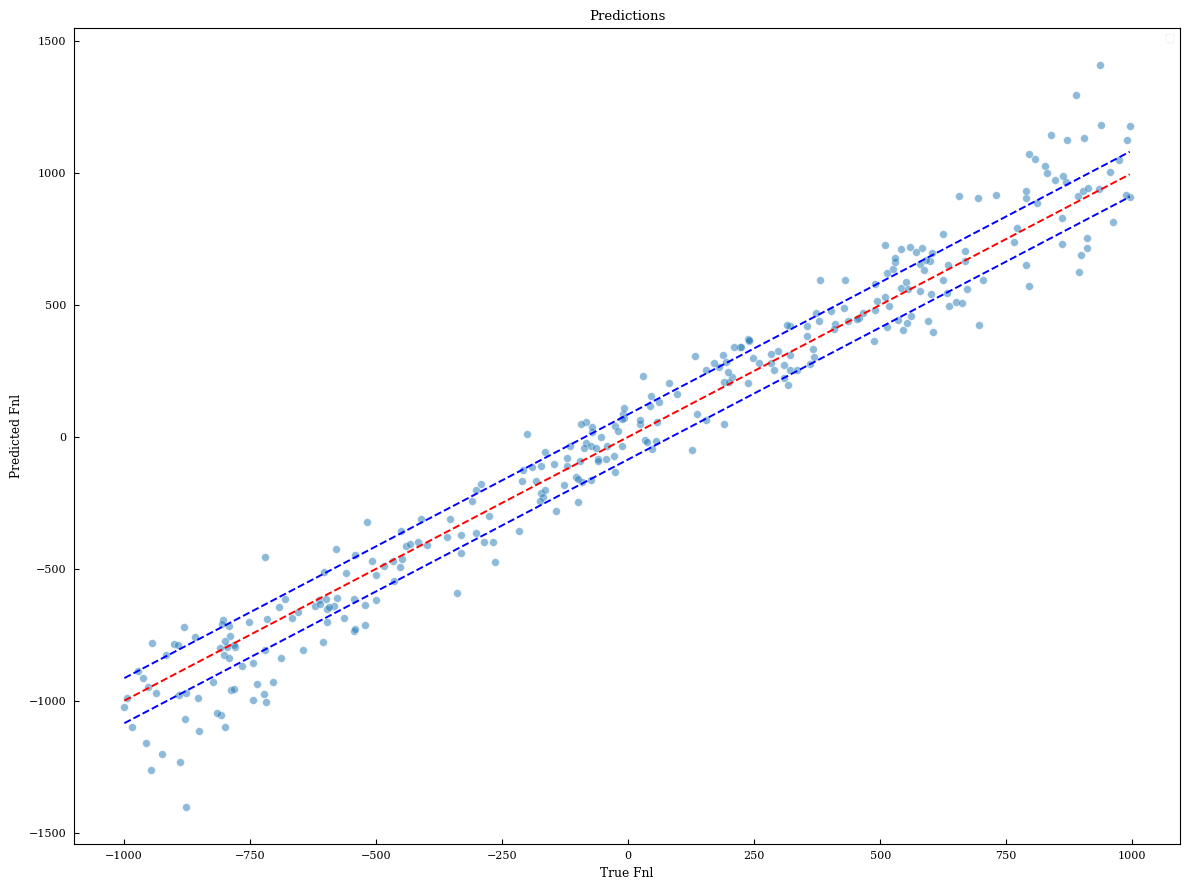

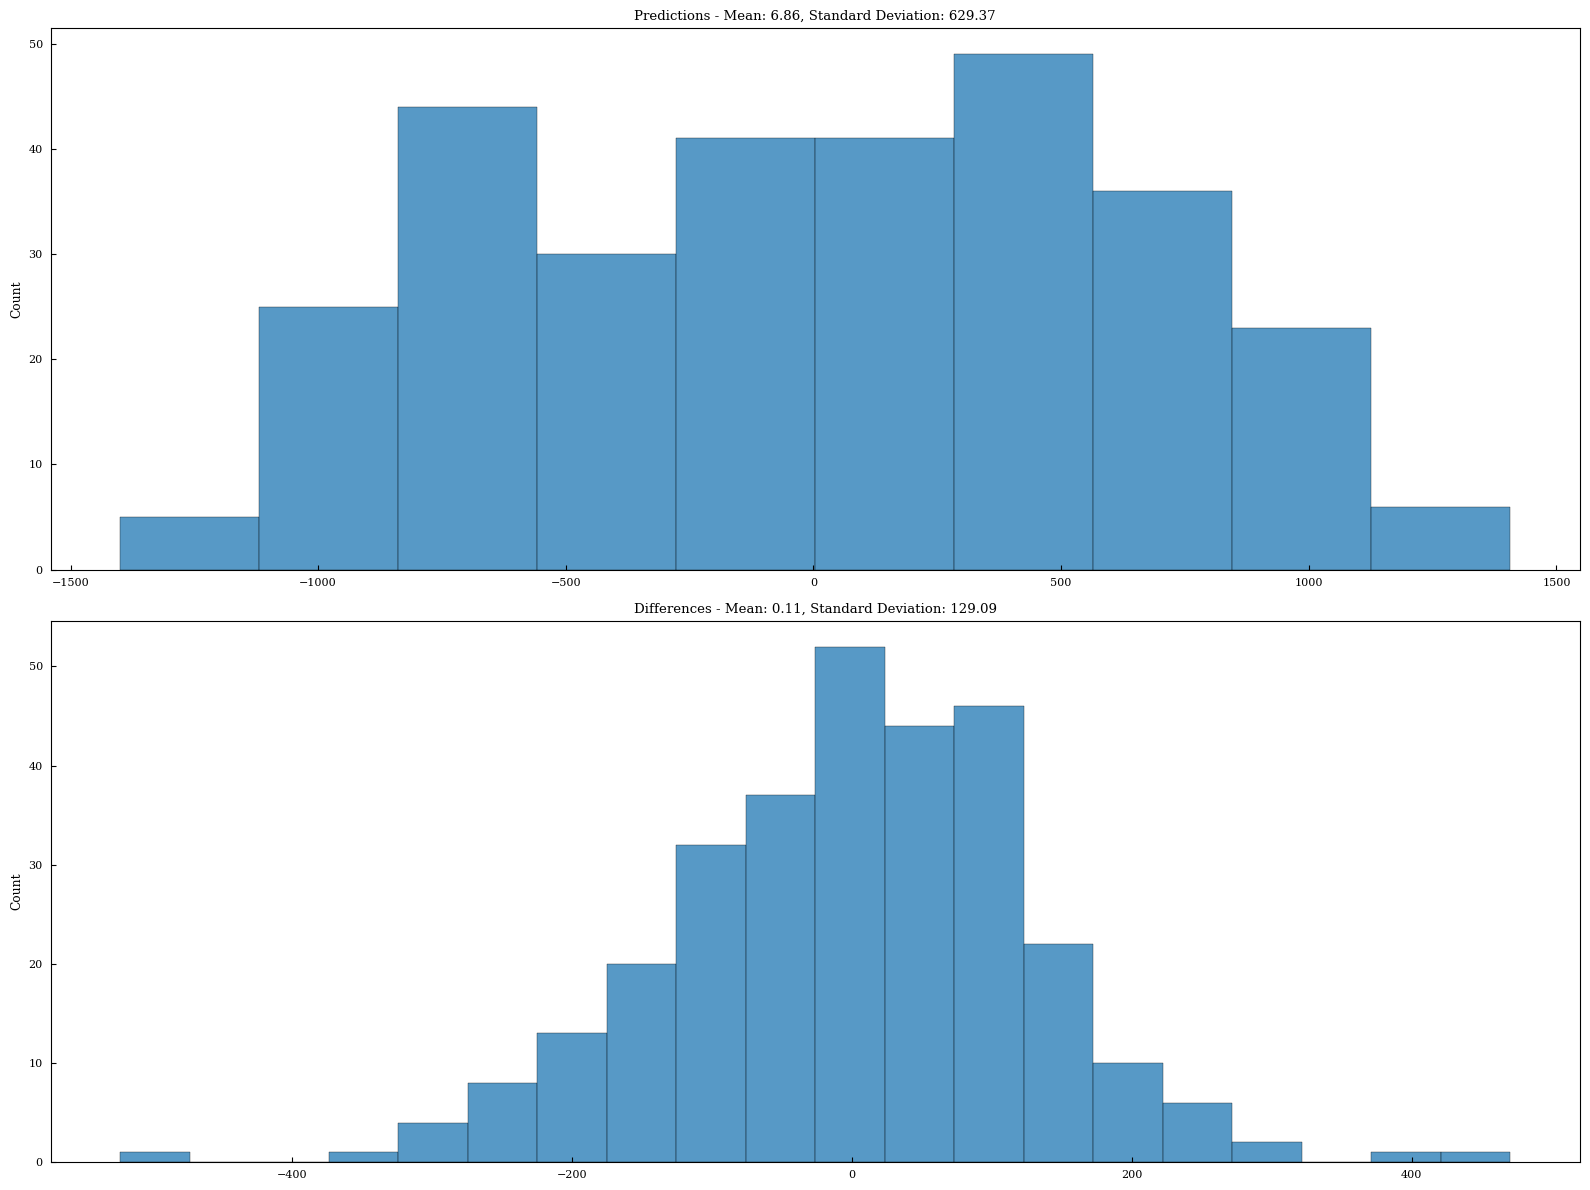

In [21]:
print(
    "fnl shape", fnls.shape, "estimates shape", lens_estimates.shape, "fisher", fisher
)
fnls_flat = fnls[:, 0, 0]
print_errors(fnls_flat, lens_estimates, fisher)
plot_predictions(fnls_flat, lens_estimates, sigma=1/np.sqrt(fisher), show=True)
plot_histogram(fnls_flat, lens_estimates, show=True)